Student Performance Prediction (Regression)

In [18]:
#Upload Dataset in Google Colab
from google.colab import files
uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [19]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [21]:
#Load Dataset
import zipfile
import io

# The user uploaded 'archive (8).zip' which likely contains 'StudentsPerformance.csv'
zip_file_name = 'archive (8).zip'

# Check if the zip file exists in the uploaded files dictionary
if zip_file_name in uploaded:
    # Use io.BytesIO to treat the byte content of the uploaded file as a file
    with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
        # Extract all contents to the current directory
        z.extractall()
    print(f"'{zip_file_name}' extracted, contents should now be available.")
else:
    print(f"Error: '{zip_file_name}' not found in uploaded files. Please ensure it was uploaded correctly.")

df = pd.read_csv("StudentsPerformance.csv")
df.head()

'archive (8).zip' extracted, contents should now be available.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
#Check dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


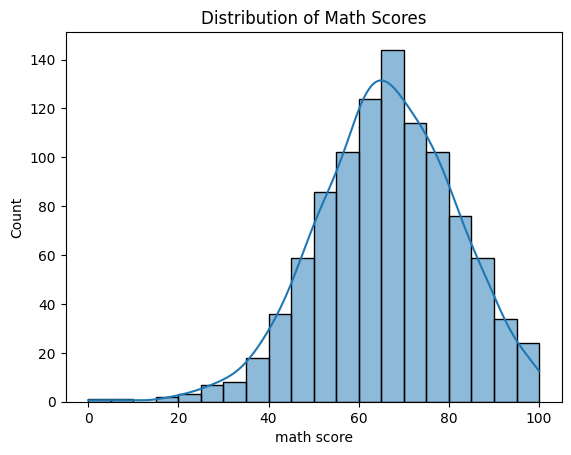

In [23]:
#Data Visualization
sns.histplot(df["math score"], bins=20, kde=True)
plt.title("Distribution of Math Scores")
plt.show()

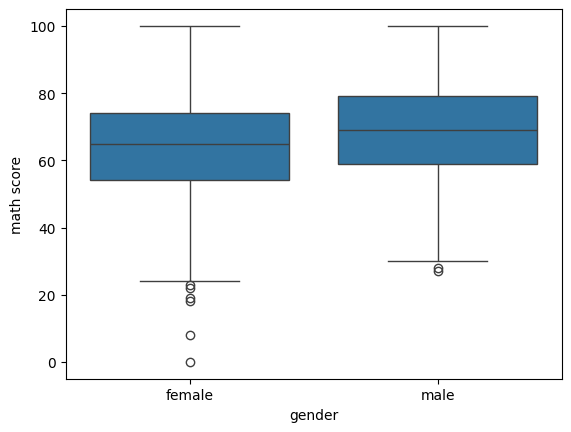

In [24]:
sns.boxplot(x="gender", y="math score", data=df)
plt.show()

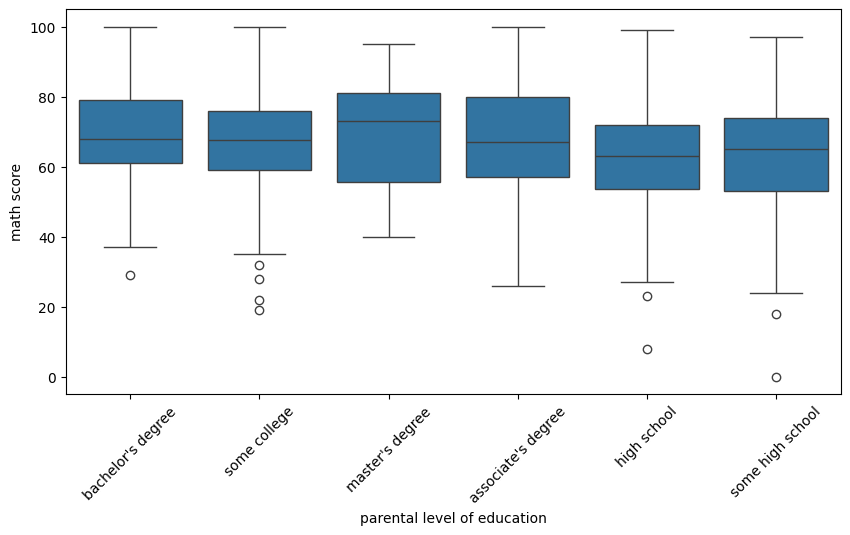

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x="parental level of education", y="math score", data=df)
plt.xticks(rotation=45)
plt.show()

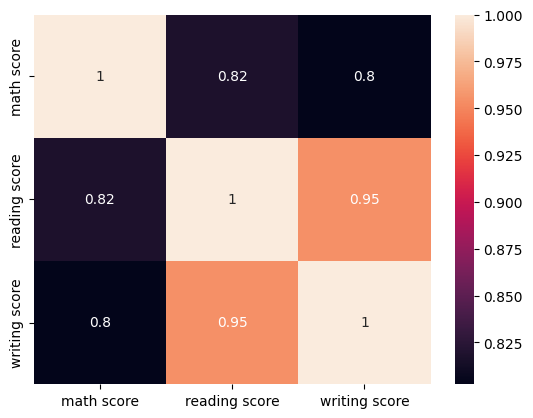

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [27]:
#Create TotalScore
 featuredf["TotalScore"] = df["math score"] + df["reading score"] + df["writing score"]

In [28]:
#Encode Categorical Features
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["lunch"] = le.fit_transform(df["lunch"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

In [29]:
#Define Features and Target
X = df[["gender","parental level of education","lunch","test preparation course","reading score","writing score","TotalScore"]]

y = df["math score"]

In [30]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
#Model Building
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [32]:
rf = RandomForestRegressor()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [33]:
gb = GradientBoostingRegressor()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

In [34]:
#Model Evaluation
print("Linear Regression")

rmse = np.sqrt(mean_squared_error(y_test,pred_lr))#lower RMSE = better model
r2 = r2_score(y_test,pred_lr)#1=perfect,0=poor model

print("RMSE:",rmse)
print("R2 Score:",r2)

Linear Regression
RMSE: 3.881691552495646e-14
R2 Score: 1.0


In [35]:
print("Random Forest")

rmse = np.sqrt(mean_squared_error(y_test,pred_rf))
r2 = r2_score(y_test,pred_rf)

print("RMSE:",rmse)
print("R2 Score:",r2)

Random Forest
RMSE: 2.819227376427804
R2 Score: 0.9673374896851463


In [36]:
print("Gradient Boosting")

rmse = np.sqrt(mean_squared_error(y_test,pred_gb))
r2 = r2_score(y_test,pred_gb)

print("RMSE:",rmse)
print("R2 Score:",r2)

Gradient Boosting
RMSE: 3.256171336493597
R2 Score: 0.9564283657137447


In [37]:
#Model Optimization
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200],
    "max_depth":[3,5,10]
}

grid = GridSearchCV(RandomForestRegressor(),params,cv=5)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


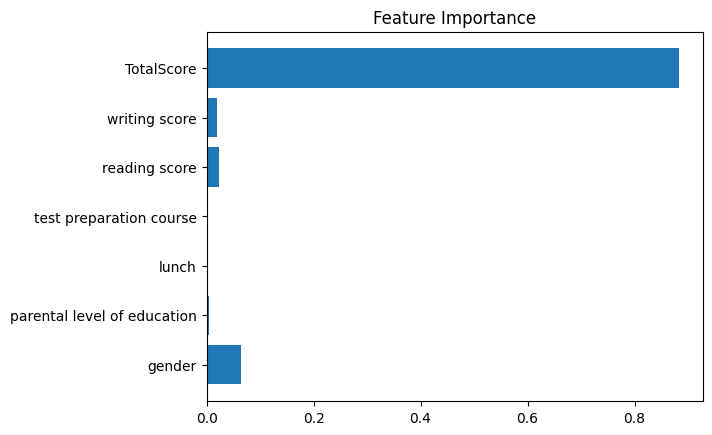

In [38]:
#Feature Importance
importance = rf.feature_importances_

features = X.columns

plt.barh(features,importance)
plt.title("Feature Importance")
plt.show()